# Generating New Fonts using Conditional Generative Adversarial Networks
Kalp Shah, Indian Institute of Technology Gandhinagar

## Downloading and Extracting TMNIST Alphabet Dataset from Kaggle

Typography MNIST (TMNIST)

MNIST style images of the following 94 alphabetic characters:

{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\', ']', '^', '_', '`', '{', '|', '}', '~'}

This repository contains a single csv .file.
The structure of the csv file is:

The first row contains column headers `['names', 'labels','1','2',…..'784']`
The `names` column contains font file names such as 'Acme-Regular' and 'ZillaSlab-Bold'. The `labels` column contains characters such as '@','E' or '+'
The remaining 784 columns contain the grayscale pixel values for the image of the corresponding character in the `name` font-style. This dataset contains over 281,000 images and is part of the Warhol.ai Computational Creativity and Cognitive Type projects.

Link to [Kaggle](https://www.kaggle.com/datasets/nikbearbrown/tmnist-alphabet-94-characters). Dataset by `NIKBEARBROWN` on Kaggle.

In [2]:
!kaggle datasets download -d nikbearbrown/tmnist-alphabet-94-characters

Dataset URL: https://www.kaggle.com/datasets/nikbearbrown/tmnist-alphabet-94-characters
License(s): Attribution 3.0 Unported (CC BY 3.0)
100% 84.7M/84.7M [00:00<00:00, 115MB/s]



In [3]:
import zipfile
import os

zip_file_path = '/content/tmnist-alphabet-94-characters.zip'
extraction_path = '/content/tmnist_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped to: {extraction_path}")
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Dataset unzipped to: /content/tmnist_data
Contents of the extracted directory:
/content/tmnist_data/94_character_TMNIST.csv


In [4]:
import pandas as pd
import numpy as np

csv_file_path = '/content/tmnist_data/94_character_TMNIST.csv'
df = pd.read_csv(csv_file_path)

print("Dataset loaded successfully into a pandas DataFrame.")
print("Displaying the first 5 rows of the DataFrame:")
display(df.head())

Dataset loaded successfully into a pandas DataFrame.
Displaying the first 5 rows of the DataFrame:


,names,labels,1,2,3,4,5,6,7,8,...,775,776,777,778,779,780,781,782,783,784
0,Salsa-Regular,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MouseMemoirs-Regular,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Creepster-Regular,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SeoulNamsan-Light,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HachiMaruPop-Regular,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(f"DataFrame shape: {df.shape}")
display(df.head())

DataFrame shape: (274093, 786)


,names,labels,1,2,3,4,5,6,7,8,...,775,776,777,778,779,780,781,782,783,784
0,Salsa-Regular,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MouseMemoirs-Regular,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Creepster-Regular,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SeoulNamsan-Light,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HachiMaruPop-Regular,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Engineering and Preprocessing

In [14]:
from sklearn.preprocessing import LabelEncoder

# Extract the style string (defaulting to 'Regular' if no hyphen exists)
df['style_string'] = df['names'].apply(lambda x: x.split('-')[-1] if '-' in x else 'Regular')

# Create binary condition flags
df['is_bold'] = df['style_string'].str.contains('Bold', case=False).astype(int)
df['is_italic'] = df['style_string'].str.contains('Italic', case=False).astype(int)
df['is_light'] = df['style_string'].str.contains('Light', case=False).astype(int)
df['is_regular'] = df['style_string'].str.contains('Regular', case=False).astype(int)

# Extract pixel data and reshape
pixel_cols = [str(i) for i in range(1, 785)]
images = df[pixel_cols].values.reshape(-1, 28, 28, 1)

# Normalize images to [-1, 1] for the GAN's Tanh activation
images = (images.astype(np.float32) - 127.5) / 127.5

# Encode character labels to numerical format
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df['labels'])

## Dataset and Condition Vector Construction

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class TMNISTConditionalDataset(Dataset):
    def __init__(self, images, labels, styles):
        """
        images: Numpy array of shape (N, 28, 28, 1) normalized to [-1, 1]
        labels: Numpy array of integer-encoded characters (0 to 93)
        styles: Numpy array or DataFrame of style flags (N, 4)
        """
        # Reshape to PyTorch channels-first format: (N, 1, 28, 28)
        self.images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.styles = torch.tensor(styles, dtype=torch.float32)
        self.num_classes = 94

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]

        # 1. Create one-hot encoding for the character
        char_one_hot = torch.zeros(self.num_classes)
        char_one_hot[self.labels[idx]] = 1.0

        # 2. Concatenate character one-hot vector with style flags
        style_vector = self.styles[idx]
        condition_vector = torch.cat((char_one_hot, style_vector), dim=0)

        return img, condition_vector

## cGAN Architecture

In [16]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, condition_dim=98):
        super(Generator, self).__init__()
        self.input_dim = latent_dim + condition_dim

        # Project concatenated vector and upscale via Transposed Convolutions
        self.fc = nn.Linear(self.input_dim, 7 * 7 * 128)

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2), # 7x7 -> 14x14
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2), # 14x14 -> 28x28
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32, 0.8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh() # Outputs values between -1 and 1
        )

    def forward(self, noise, labels):
        # Concatenate latent noise and condition vector
        x = torch.cat((noise, labels), dim=1)
        x = self.fc(x)
        x = x.view(-1, 128, 7, 7)
        return self.conv_blocks(x)


class Discriminator(nn.Module):
    def __init__(self, condition_dim=98):
        super(Discriminator, self).__init__()
        self.condition_dim = condition_dim

        # Linear layer to map condition vector to image spatial dimensions
        self.conditional_embedding = nn.Linear(condition_dim, 1 * 28 * 28)

        self.model = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=3, stride=2, padding=1), # Channel input is 2 (Image + Condition layer)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            # Removed nn.ZeroPad2d((0, 1, 0, 1)) as it caused dimension mismatch
            nn.BatchNorm2d(128, 0.8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Embed condition vectors and reshape to map to image channels
        cond_img = self.conditional_embedding(labels).view(-1, 1, 28, 28)
        # Concatenate along the channel axis
        d_input = torch.cat((img, cond_img), dim=1)
        return self.model(d_input)

## Training Loop and Cohesive Font Generation
Handles the standard cGAN training configuration using Binary Cross Entropy Loss

In [18]:
# Hyperparameters
latent_dim = 100
condition_dim = 98
lr = 0.0002
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize models
generator = Generator(latent_dim, condition_dim).to(device)
discriminator = Discriminator(condition_dim).to(device)

adversarial_loss = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Standard Training Iteration Example
def train_step(real_imgs, conditions):
    batch_size = real_imgs.size(0)
    valid = torch.ones(batch_size, 1, device=device)
    fake = torch.zeros(batch_size, 1, device=device)

    # ----------------- Train Generator -----------------
    optimizer_G.zero_grad()
    z = torch.randn(batch_size, latent_dim, device=device)
    gen_imgs = generator(z, conditions)
    g_loss = adversarial_loss(discriminator(gen_imgs, conditions), valid)
    g_loss.backward()
    optimizer_G.step()

    # ---------------- Train Discriminator ----------------
    optimizer_D.zero_grad()
    real_loss = adversarial_loss(discriminator(real_imgs, conditions), valid)
    fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), conditions), fake)
    d_loss = (real_loss + fake_loss) / 2
    d_loss.backward()
    optimizer_D.step()

In [19]:
import torch
from torch.utils.data import DataLoader

# 1. Initialize Dataset and DataLoader
# 'images' and 'labels' come from Phase 1.
# Extract the style flags directly from the DataFrame we built:
styles_array = df[['is_bold', 'is_italic', 'is_light', 'is_regular']].values

dataset = TMNISTConditionalDataset(images, labels, styles_array)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# 2. Set Training Parameters
num_epochs = 50 # Start with 50-100 epochs depending on your hardware
print("Starting Training Loop...")

# 3. The Outer Loop
for epoch in range(num_epochs):
    # The Inner Batch Loop
    for i, (imgs, conditions) in enumerate(dataloader):

        # Move data to the active device (GPU or CPU)
        real_imgs = imgs.to(device)
        conditions = conditions.to(device)

        curr_batch_size = real_imgs.size(0)

        # Ground truth labels for the loss function
        valid = torch.ones(curr_batch_size, 1, device=device)
        fake = torch.zeros(curr_batch_size, 1, device=device)

        # ==========================================
        # Train Generator
        # ==========================================
        optimizer_G.zero_grad()

        # Sample random noise as generator input
        z = torch.randn(curr_batch_size, latent_dim, device=device)

        # Generate a batch of images
        gen_imgs = generator(z, conditions)

        # Generator Loss: The generator wants the discriminator to evaluate its fake images as 'valid' (1)
        g_loss = adversarial_loss(discriminator(gen_imgs, conditions), valid)

        g_loss.backward()
        optimizer_G.step()

        # ==========================================
        # Train Discriminator
        # ==========================================
        optimizer_D.zero_grad()

        # Discriminator Loss on Real Images
        real_loss = adversarial_loss(discriminator(real_imgs, conditions), valid)

        # Discriminator Loss on Fake Images
        # We use .detach() here so gradients don't flow back into the Generator during D's update
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), conditions), fake)

        # Total Discriminator Loss is the average of both
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        # ==========================================
        # Progress Logging
        # ==========================================
        if i % 200 == 0:
            print(
                f"[Epoch {epoch}/{num_epochs}] "
                f"[Batch {i}/{len(dataloader)}] "
                f"[D loss: {d_loss.item():.4f}] "
                f"[G loss: {g_loss.item():.4f}]"
            )

print("Training Complete!")

# 4. Save Your Model Weights
torch.save(generator.state_dict(), "cgan_generator_weights.pth")
torch.save(discriminator.state_dict(), "cgan_discriminator_weights.pth")
print("Model weights saved successfully.")

Starting Training Loop...
[Epoch 0/50] [Batch 0/4282] [D loss: 0.6881] [G loss: 0.6854]
[Epoch 0/50] [Batch 200/4282] [D loss: 0.6762] [G loss: 0.7435]
[Epoch 0/50] [Batch 400/4282] [D loss: 0.6667] [G loss: 0.7231]
[Epoch 0/50] [Batch 600/4282] [D loss: 0.7049] [G loss: 0.7760]
[Epoch 0/50] [Batch 800/4282] [D loss: 0.5791] [G loss: 0.8128]
[Epoch 0/50] [Batch 1000/4282] [D loss: 0.6068] [G loss: 0.9303]
[Epoch 0/50] [Batch 1200/4282] [D loss: 0.6980] [G loss: 0.7058]
[Epoch 0/50] [Batch 1400/4282] [D loss: 0.6563] [G loss: 0.7023]
[Epoch 0/50] [Batch 1600/4282] [D loss: 0.6663] [G loss: 0.8427]
[Epoch 0/50] [Batch 1800/4282] [D loss: 0.6613] [G loss: 0.7269]
[Epoch 0/50] [Batch 2000/4282] [D loss: 0.6454] [G loss: 0.8542]
[Epoch 0/50] [Batch 2200/4282] [D loss: 0.6817] [G loss: 0.7767]
[Epoch 0/50] [Batch 2400/4282] [D loss: 0.6947] [G loss: 0.8131]
[Epoch 0/50] [Batch 2600/4282] [D loss: 0.6620] [G loss: 0.7504]
[Epoch 0/50] [Batch 2800/4282] [D loss: 0.6205] [G loss: 0.7483]
[Epoch

## Generating a New Font

##

In [20]:
def generate_custom_font(style_flags=[0.0, 0.0, 0.0, 0.0]):
    """
    style_flags: List corresponding to [is_bold, is_italic, is_light, is_regular]
    Example: [0.0, 1.0, 0.0, 0.0] ensures the output is exclusively italic and not bold.
    """
    generator.eval()
    font_alphabet = {}

    # CRITICAL: Freeze ONE specific random noise vector. This constitutes the identity of your font.
    shared_latent_dna = torch.randn(1, latent_dim, device=device)
    style_tensor = torch.tensor(style_flags, dtype=torch.float32, device=device)

    with torch.no_grad():
        for char_idx in range(94):
            # Form character configuration
            char_one_hot = torch.zeros(94, device=device)
            char_one_hot[char_idx] = 1.0

            # Form complete condition tensor
            condition = torch.cat((char_one_hot, style_tensor)).unsqueeze(0)

            # Generate character image
            generated_char = generator(shared_latent_dna, condition)
            font_alphabet[char_idx] = generated_char.squeeze().cpu().numpy()

    return font_alphabet

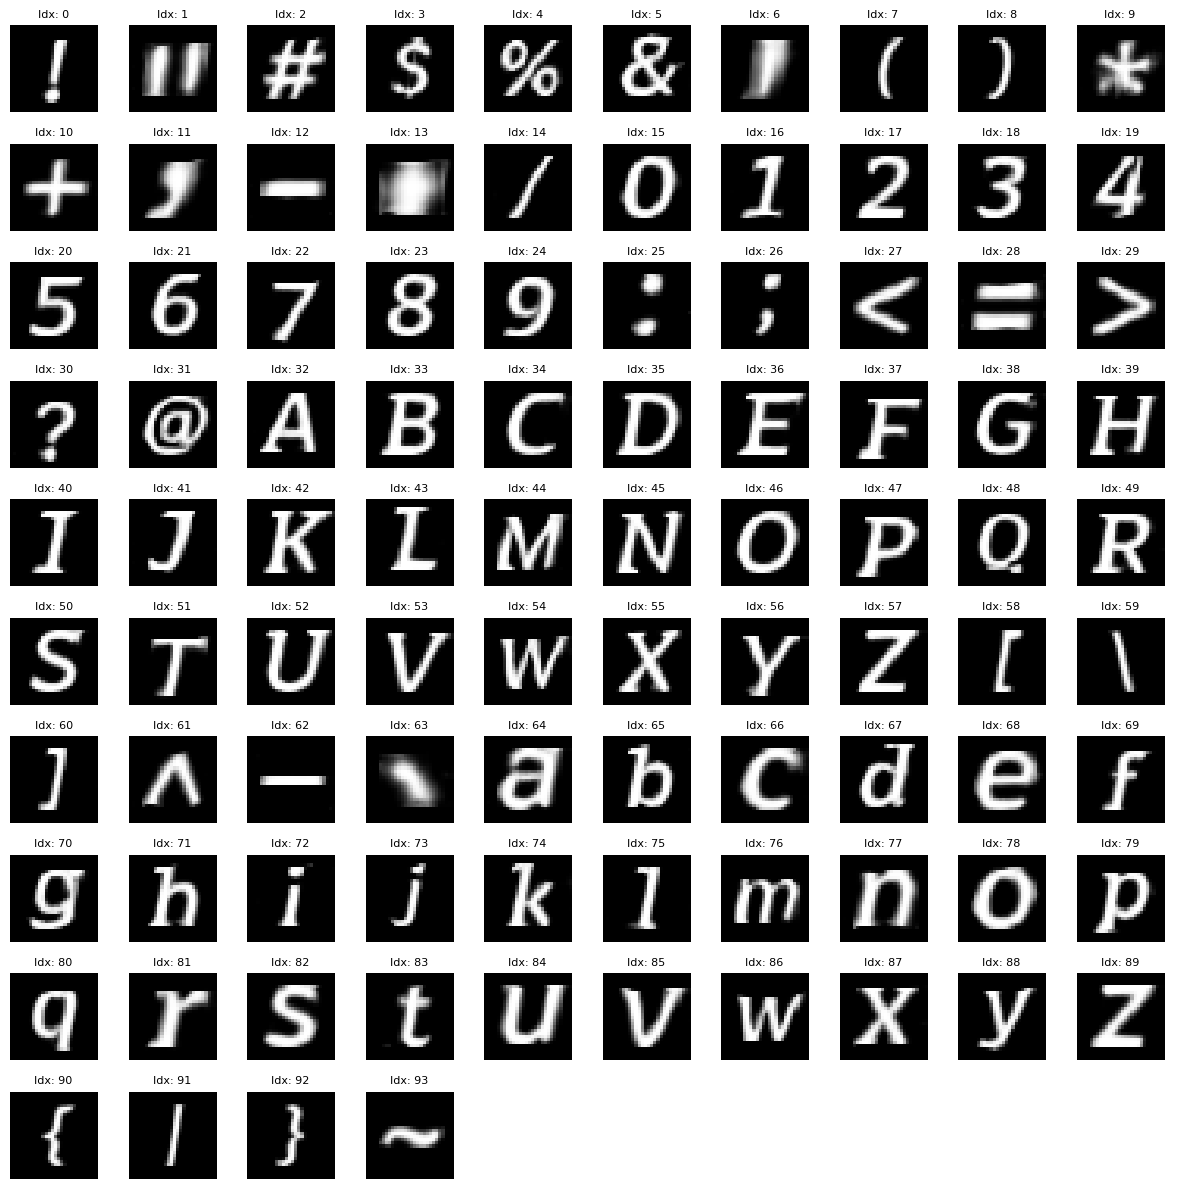

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_font_grid(font_alphabet, num_cols=10):
    """
    Plots the generated font alphabet in a grid.
    font_alphabet: Dictionary of {char_index: 28x28 numpy array}
    """
    num_chars = len(font_alphabet)
    # Calculate rows needed for a 10-column grid
    num_rows = int(np.ceil(num_chars / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 1.2, num_rows * 1.2))
    axes = axes.flatten()

    for idx in range(num_rows * num_cols):
        ax = axes[idx]
        ax.axis('off') # Hide the axis ticks and borders

        if idx < num_chars:
            img = font_alphabet[idx]

            # Denormalize the image from [-1, 1] to [0, 1] for rendering
            img = (img + 1.0) / 2.0

            ax.imshow(img, cmap='gray')

            # Optional: Label the image with its index
            # (If you kept your LabelEncoder, you can replace idx with the actual character)
            ax.set_title(f"Idx: {idx}", fontsize=8)

    plt.tight_layout()
    plt.show()

# Generate your custom font (e.g., both Italic and Bold)
my_custom_font = generate_custom_font(style_flags=[1.0, 1.0, 0.0, 0.0])

# Render the grid
visualize_font_grid(my_custom_font)